# Conformal Inference

https://matheusfacure.github.io/python-causality-handbook/Conformal-Inference-for-Synthetic-Control.html

https://arxiv.org/pdf/1712.09089.pdf

In [1]:
import sys
sys.path.insert(0, '..')
from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
from panel_exp.methods.tbr import TBR, TBRRidge
import numpy as np

from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife, time_jackknife_plus

In [2]:
long_df = pd.read_csv('smoking.csv')
long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']
panel = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California" ], [1988 ]) 


In [3]:
pre_t_time = panel.treated_start_idxs[0]-1
n_treated_units = len(panel.treated_units)
n_treated_time_periods = (panel.treated_end_idxs[0] - panel.treated_start_idxs[0])


In [4]:
print((panel.treated_end_idxs[0] , panel.treated_start_idxs[0]))

(30, 18)


In [5]:
print((panel.treated_end_idxs[0] - panel.treated_start_idxs[0]))

print(panel.times[panel.treated_end_idxs[0]] , panel.times[panel.treated_start_idxs[0]] )

12
2000 1988


In [6]:
panel.treated_end_idxs[0]

30

In [7]:
panel.wide_data.shape

(39, 31)

In [8]:
panel.wide_data.loc[:, 1988:]

time_unit,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000
unit,,,,,,,,,,,,,
Alabama,112.099998,105.599998,108.599998,107.900002,109.099998,108.500000,107.099998,102.599998,101.400002,104.900002,106.199997,100.699997,96.199997
Arkansas,121.500000,118.300003,113.099998,116.800003,126.000000,113.800003,108.800003,113.000000,110.699997,108.699997,109.500000,104.800003,99.400002
California,90.099998,82.400002,77.800003,68.699997,67.500000,63.400002,58.599998,56.400002,54.500000,53.799999,52.299999,47.200001,41.599998
Colorado,94.599998,88.800003,87.400002,90.199997,88.300003,88.599998,89.099998,85.400002,83.099998,81.300003,81.199997,79.599998,73.000000
Connecticut,104.800003,100.599998,91.500000,86.699997,83.500000,79.099998,76.599998,79.300003,76.000000,75.900002,75.500000,73.400002,71.400002
Delaware,137.100006,131.699997,127.199997,118.800003,120.000000,123.800003,126.099998,127.199997,128.300003,124.099998,132.800003,139.500000,140.699997
Georgia,124.099998,117.099998,113.800003,109.599998,109.199997,109.199997,107.800003,100.300003,102.699997,100.599998,100.500000,97.099998,88.400002
Idaho,84.500000,78.400002,90.099998,85.400002,85.099998,86.699997,93.000000,78.199997,73.599998,75.000000,78.900002,75.099998,66.900002
Illinois,107.599998,104.599998,94.099998,96.099998,94.800003,94.599998,85.699997,84.300003,81.800003,79.599998,80.300003,72.199997,70.000000


In [9]:
#scm_1 = SyntheticControl(inference='JKP' )
#scm_1.run_analysis(panel)
#scm_1.plot()




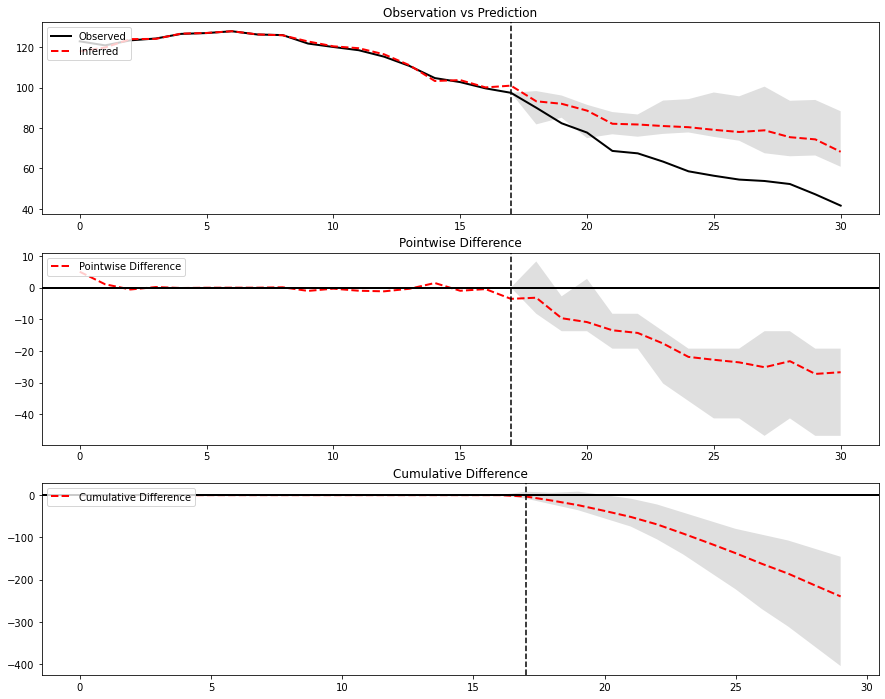

In [10]:

scm_1 = SyntheticControl(inference='Conformal' )
scm_1.run_analysis(panel)
scm_1.plot()

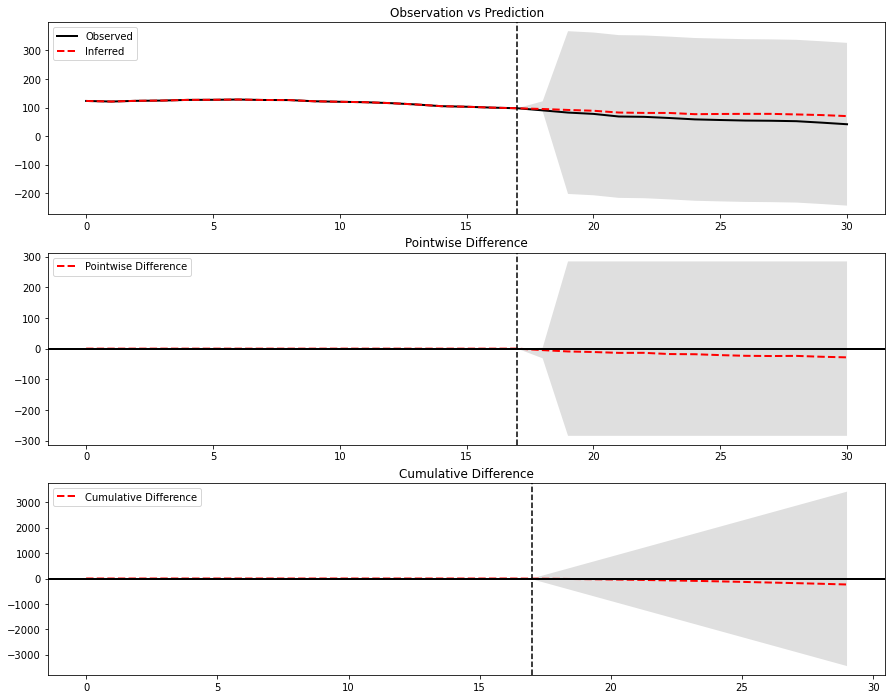

In [11]:
from panel_exp.methods.tbr import TBR, TBRRidge

est = TBRRidge(inference='Conformal' )
est.run_analysis(panel)
est.plot()

In [14]:
long_df = pd.read_csv('kansas_parsed.csv')
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas" ], [2012])


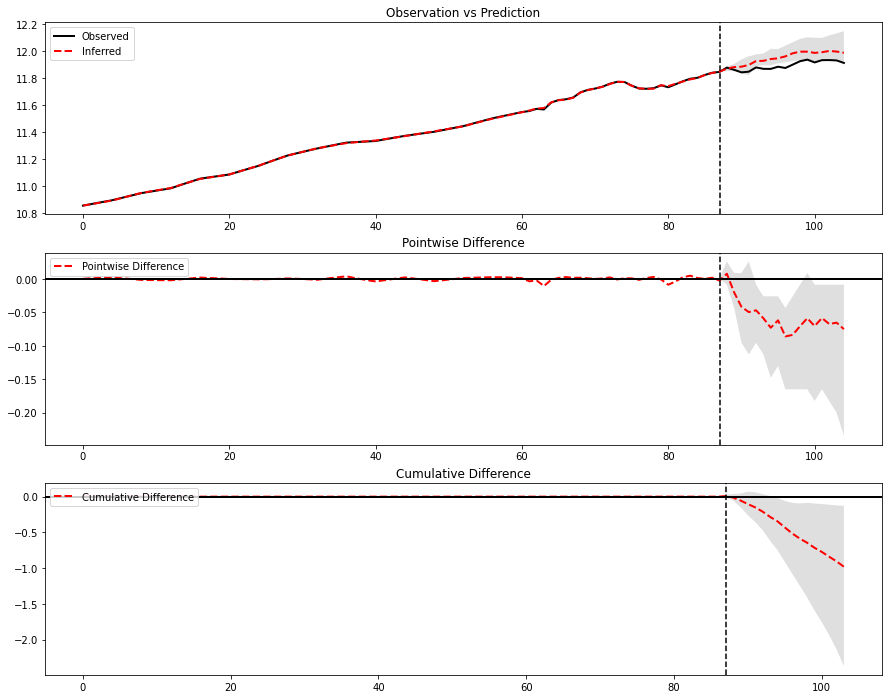

In [16]:
est = TBRRidge(inference='Conformal' )
est.run_analysis(panel_data)
est.plot()


# Issue One

I auto generate potential null hypothesis to test against (line 126 of impact ABC). The 1-alpha CI might get cut off if this is not a good estimate, so we'll need to update to pass a custom list. 

Choosing them is not easy

## AugSynth Below

In [11]:
long_df = pd.read_csv('kansas_parsed.csv')
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas" ], [2012])


In [15]:
asynth = AugSynth(inference='Conformal', outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])

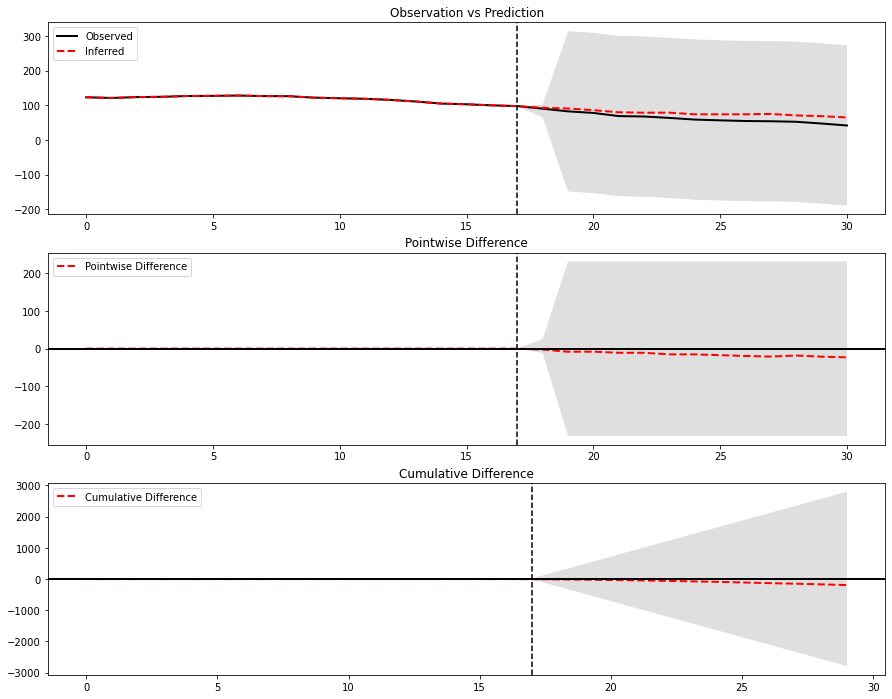

In [16]:
asynth.run_analysis(pds, outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])

asynth.plot()

In [11]:
from panel_exp.methods.tbr import TBR, TBRRidge


In [17]:
long_df = pd.read_csv('kansas_parsed.csv')
long_df.head()

long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']

panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas"], 2012)

print(panel_data.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


In [18]:
wide = pd.pivot_table(long_df, columns='time_unit', index='unit', values = 'value', aggfunc=sum, fill_value=0)
treated = ['Kansas']
control_units = pd.DataFrame(wide.loc[[c for c in wide.index if c not in treated]].mean(axis=0), columns=['controls']).T
treated_units = wide.loc[treated]

wide_agg = pd.concat([treated_units, control_units])
panel_data = PanelDataset(wide_agg, treated_units = treated, treated_periods=[TimePeriod(start=2012)])


In [19]:
tbr = TBR(inference='Conformal')
tbr.run_analysis(panel_data)
tbr.plot()

AssertionError: TBR requires control units to be pre-aggregated. Try TBRRidge or aggregate control units

In [20]:
long_df = pd.read_csv('kansas_parsed.csv')
long_df.head()

long_df.columns = ['un', 'value', 'treated', 'fips', 'time_unit', 'unit']

panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "value", ["Kansas"], 2012)

print(panel_data.summarize())



        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 50
        Number of treated units: 1
        Treated units: ['Kansas']
        Treated periods: [TimePeriod(start=2012, end=None)]
        


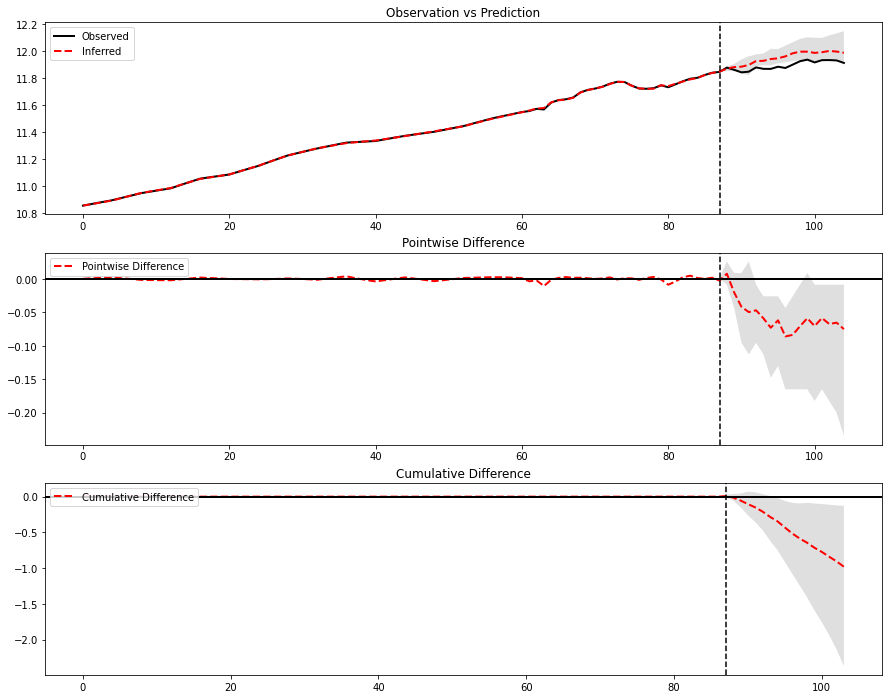

In [21]:
tbr = TBRRidge(inference='Conformal')
tbr.run_analysis(panel_data)
tbr.plot()

<AxesSubplot:xlabel='time_unit'>

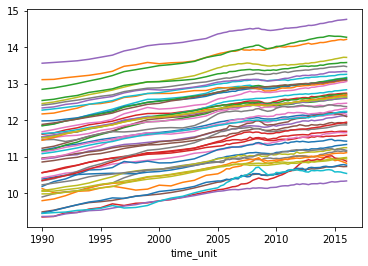

In [29]:
panel_data.wide_data.T.plot(legend=False)

<AxesSubplot:xlabel='time_unit'>

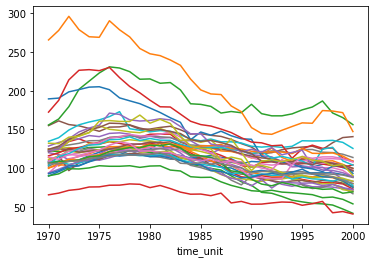

In [28]:
pds.wide_data.T.plot(legend=False)

In [ ]:
'''
While Conformal Inference is proven to be robust in many scenarios, it is not guaranteed to work everytime. Most commonly, Conformal Inference can fail when

there is not enough days in the Pre-Treatment Period
the true impact (called in the paper as Shock Sequence Ut) is not stationary or not weakly dependent
the data is not stationary and not weakly dependent 
when our model is misspecified or inconsistent

'''

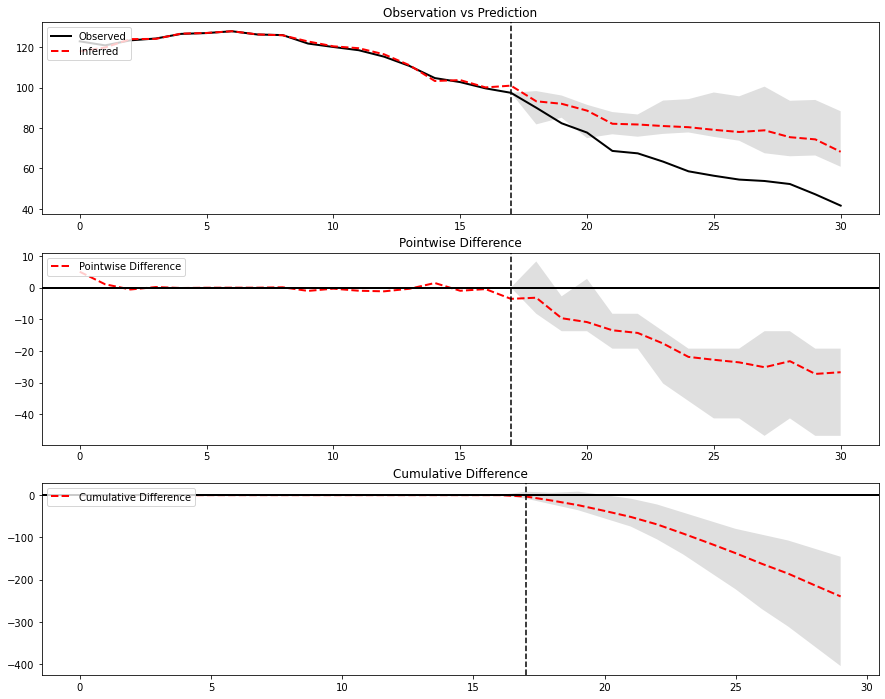

In [30]:
scm_1 = SyntheticControl(inference='Conformal' )
scm_1.run_analysis(pds)
scm_1.plot()

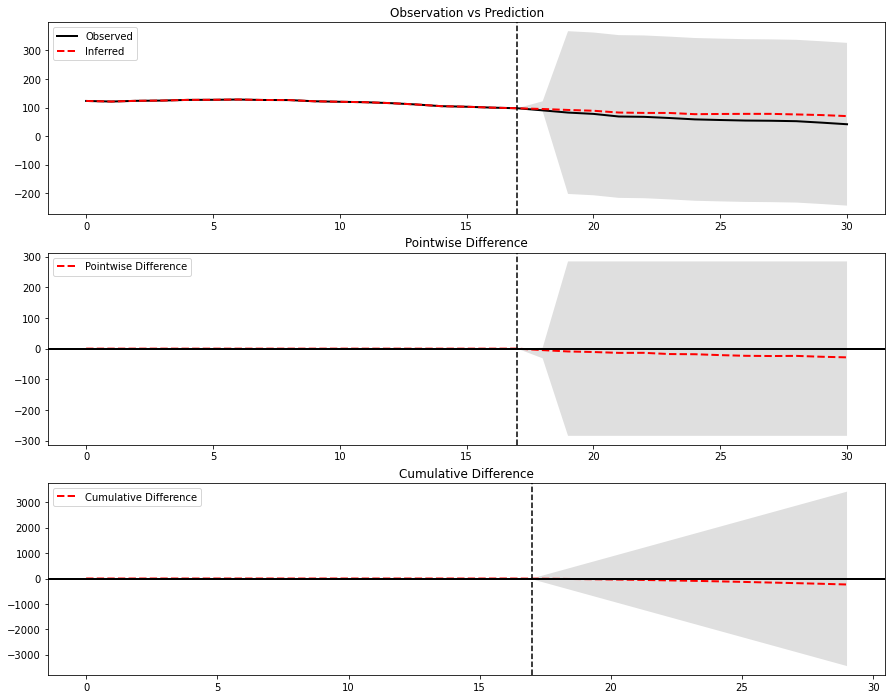

In [22]:
tbr = TBRRidge(inference='Conformal')
tbr.run_analysis(pds)
tbr.plot()

In [ ]:
# DID

In [17]:
from panel_exp.methods.DID import DID

In [18]:
long_df = pd.read_csv('smoking.csv')

In [19]:
long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']

In [24]:
panel_data = long_df_to_paneldataset(long_df, "time_unit", "unit", "y", ["California"], 1989)


In [25]:
did = DID()

In [26]:
did.run_analysis(panel_data)

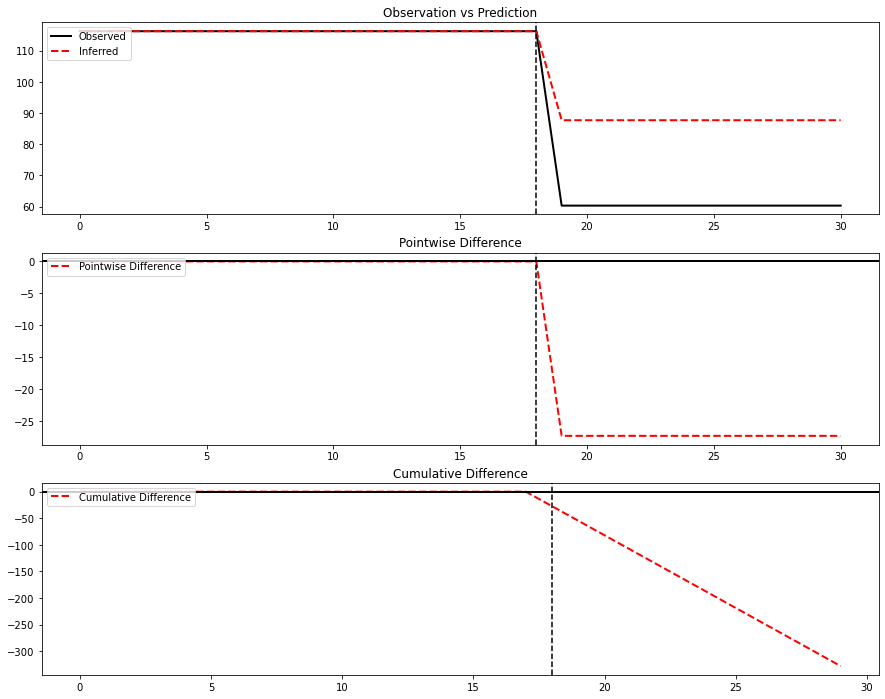

In [27]:
did.plot()

In [2]:
#JK+

data = pd.read_csv('../meta_geo.csv')

In [3]:
wide_df = pd.pivot_table(data, index='location', columns='time', values='Y')

pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105), TimePeriod(start =91, end=105)], ["chicago", "portland"])

In [4]:
pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 40
        Number of treated units: 2
        Treated units: ['chicago', 'portland']
        Treated periods: [TimePeriod(start=91, end=105), TimePeriod(start=91, end=105)]
        

In [5]:
scm_1 = TBRRidge(inference='JKP' )
scm_1.run_analysis(pds)
scm_1.plot()

ValueError: cannot reshape array of size 30 into shape (13,2)

In [167]:
from typing import Callable, Optional, Callable, Dict

def resolve_end_period(time_period):
    if time_period.end is None:
        return None
    else:
        return time_period.end+1
    
    

def jkp(panel: PanelDataset, estimator: Callable , alpha = .1 , **estimator_kwargs) -> np.array:
     
    pre_t_time = panel.treated_start_idxs[0]-1
    n_treated_units = len(panel.treated_units)
    n_treated_time_periods = (panel.treated_end_idxs[0] - panel.treated_start_idxs[0])+1
    
    lower_df = np.zeros((pre_t_time
              , n_treated_time_periods
              , n_treated_units))

    upper_df = np.zeros((pre_t_time
              , n_treated_time_periods
              , n_treated_units))

    for t_unit in range(pre_t_time):

        # drop t unit from pre-treatment periods
        new_wide_df = panel.wide_data.drop(panel.times[t_unit], axis=1)

        # append to end
        new_wide_df = new_wide_df.assign(new_column = panel.wide_data.loc[:, panel.times[t_unit]]).rename(columns={"new_column": panel.times[-1]+1})

        # new PDS
        new_pds = PanelDataset(new_wide_df
                               , [TimePeriod(start=tp.start, end=resolve_end_period(tp)) for tp in panel.treated_periods]
                               , panel.treated_units)
        # fit new model 
        model = estimator(**estimator_kwargs)
        model.run_analysis(new_pds)

        residuals = model.results['y'][new_pds.treated_start_idxs[0]:] - model.results['y_hat'][new_pds.treated_start_idxs[0]:]
        error = np.abs(residuals[-1])

        upper = residuals[:-1] + error
        lower = residuals[:-1] - error

        lower_df[t_unit] += lower
        upper_df[t_unit] += upper
    
    return np.percentile(lower_df, alpha*100, axis=0), np.percentile(upper_df, alpha*100, axis=0)
    
    

In [169]:
upper, lower = jkp(pds,TBRRidge , alpha = .1 ) 

In [104]:
import numpy as np

residuals = model.results['y'][new_pds.treated_start_idxs[0]:] - model.results['y_hat'][new_pds.treated_start_idxs[0]:]

error = np.abs(residuals[-1])

upper = residuals[:-1] + error
lower = residuals[:-1] - error

In [151]:
import matplotlib.pyplot as plt 

lower_df.mean(axis=0).mean(axis=1) 


array([  26.67197577, -145.99702647,  -59.01326107, -137.5385917 ,
         77.45688827,  161.15620701,  365.83684266,  432.34571191,
        148.27407313,  348.35518953,   27.77714308,   31.44751405,
         78.44489367,  157.44469118,   23.00917491])

In [161]:
np.percentile(lower_df, 10, axis=0)

array([[ -245.29132497,   -81.64178769],
       [ -389.68769713,  -273.54434137],
       [ -355.61973184,  -159.30314536],
       [ -379.31490151,  -288.53288332],
       [ -259.97186247,    52.29574751],
       [ -295.36283832,   229.58799744],
       [ -289.068138  ,   628.13741019],
       [ -257.28873236,   778.90302821],
       [ -640.65376712,   587.6600975 ],
       [ -345.13209464,   683.34380803],
       [-1258.60311232,   872.0330179 ],
       [-1290.01825979,   887.22515952],
       [ -400.70261044,   227.47539762],
       [ -308.24286582,   254.81305654],
       [ -436.32923177,   112.15619806]])

In [162]:
np.percentile(upper_df, 10, axis=0)

array([[  78.02296486,  318.05036833],
       [ -59.22074608,  108.23512353],
       [ -16.04973146,  240.35389126],
       [ -38.29194866,  104.74625001],
       [  65.1853381 ,  432.06293016],
       [  49.22205675,  618.70712685],
       [  56.37897976, 1017.45632974],
       [  49.26895942, 1162.46403775],
       [-320.82614846,  963.87675825],
       [ -24.13588413, 1067.45385883],
       [-909.53036418, 1271.79451597],
       [-929.89225604, 1305.02735736],
       [ -98.61692922,  599.89445312],
       [  32.64084971,  627.7193562 ],
       [-104.3190664 ,  496.18413908]])

In [64]:


resolve_end_period(pds.treated_periods[0])

In [29]:
new_wide = pds.wide_data.drop(1970, axis=1)

In [55]:
pds.times[-1]+1

2001

In [57]:
new_wide.assign(new_column = pds.wide_data.loc[:, 1970]).rename(columns={"new_column": pds.times[-1]+1})

time_unit,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
unit,,,,,,,,,,,,,,,,,,,,,
Alabama,95.400002,101.099998,102.900002,108.199997,111.699997,116.199997,117.099998,123.000000,121.400002,123.199997,...,109.099998,108.500000,107.099998,102.599998,101.400002,104.900002,106.199997,100.699997,96.199997,89.800003
Arkansas,104.099998,103.900002,108.000000,109.699997,114.800003,119.099998,122.599998,127.300003,126.500000,131.800003,...,126.000000,113.800003,108.800003,113.000000,110.699997,108.699997,109.500000,104.800003,99.400002,100.300003
California,121.000000,123.500000,124.400002,126.699997,127.099998,128.000000,126.400002,126.099998,121.900002,120.199997,...,67.500000,63.400002,58.599998,56.400002,54.500000,53.799999,52.299999,47.200001,41.599998,123.000000
Colorado,125.500000,134.300003,137.899994,132.800003,131.000000,134.199997,132.000000,129.199997,131.500000,131.000000,...,88.300003,88.599998,89.099998,85.400002,83.099998,81.300003,81.199997,79.599998,73.000000,124.800003
Connecticut,117.599998,110.800003,109.300003,112.400002,110.199997,113.400002,117.300003,117.500000,117.400002,118.000000,...,83.500000,79.099998,76.599998,79.300003,76.000000,75.900002,75.500000,73.400002,71.400002,120.000000
Delaware,161.100006,156.300003,154.699997,151.300003,147.600006,153.000000,153.300003,155.500000,150.199997,150.500000,...,120.000000,123.800003,126.099998,127.199997,128.300003,124.099998,132.800003,139.500000,140.699997,155.000000
Georgia,115.699997,117.000000,119.800003,123.699997,122.900002,125.900002,127.900002,130.600006,131.000000,134.000000,...,109.199997,109.199997,107.800003,100.300003,102.699997,100.599998,100.500000,97.099998,88.400002,109.900002
Idaho,108.500000,126.099998,121.800003,125.599998,123.300003,125.099998,125.000000,122.800003,117.500000,115.199997,...,85.099998,86.699997,93.000000,78.199997,73.599998,75.000000,78.900002,75.099998,66.900002,102.400002
Illinois,125.599998,126.599998,124.400002,131.899994,131.800003,134.399994,134.000000,136.699997,135.300003,135.199997,...,94.800003,94.599998,85.699997,84.300003,81.800003,79.599998,80.300003,72.199997,70.000000,124.800003


In [37]:
pds.wide_data.loc[:, 1970]

unit
Alabama            89.800003
Arkansas          100.300003
California        123.000000
Colorado          124.800003
Connecticut       120.000000
Delaware          155.000000
Georgia           109.900002
Idaho             102.400002
Illinois          124.800003
Indiana           134.600006
Iowa              108.500000
Kansas            114.000000
Kentucky          155.800003
Louisiana         115.900002
Maine             128.500000
Minnesota         104.300003
Mississippi        93.400002
Missouri          121.300003
Montana           111.199997
Nebraska          108.099998
Nevada            189.500000
New Hampshire     265.700012
New Mexico         90.000000
North Carolina    172.399994
North Dakota       93.800003
Ohio              121.599998
Oklahoma          108.400002
Pennsylvania      107.300003
Rhode Island      123.900002
South Carolina    103.599998
South Dakota       92.699997
Tennessee          99.800003
Texas             106.400002
Utah               65.500000
Vermont  